In [ ]:
%pip install --index-url https://test.pypi.org/simple/ --extra-index-url https://pypi.org/simple/ synthesize==2.0

In [1]:
%load_ext autoreload
%autoreload 2

# 添加当前目录到 Python 路径
import sys
import os
sys.path.insert(0, os.path.dirname(os.path.abspath('')))

# 从本地 tools 模块导入函数
try:
    from tools import get_data_metrics, visualize, eval_classifier, vis_classifier
except ImportError:
    # 如果直接导入失败，尝试从当前目录导入
    import importlib.util
    spec = importlib.util.spec_from_file_location("tools", "tools.py")
    tools_module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(tools_module)
    get_data_metrics = tools_module.get_data_metrics
    visualize = tools_module.visualize
    eval_classifier = tools_module.eval_classifier
    vis_classifier = tools_module.vis_classifier
import pandas as pd
import numpy as np

/Users/yanjiechen/Documents/Github/SyntheSize_py/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


plotnine is already installed.
pandas is already installed.
matplotlib is already installed.
seaborn is already installed.
xgboost is already installed.
numpy is already installed.
scipy is already installed.


# PRADSubtype quality evaluation

倒数第二列不全为0，使用原始文件
检测到文件 /Users/yanjiechen/Documents/Github/SyNG-BTS/syng_bts/Case/test_results/COAD_5-2/raw/batch_2/CVAE1-50/COAD_5-2_raw_batch_2_test.csv 的最后两列为'samples, groups'，正在交换顺序...
已创建交换列后的临时文件: /Users/yanjiechen/Documents/Github/SyNG-BTS/syng_bts/Case/test_results/COAD_5-2/raw/batch_2/CVAE1-50/swap_cols_temp_8_f66i0t.csv
文件 /Users/yanjiechen/Documents/Github/SyNG-BTS/syng_bts/Case/test_results/COAD_5-2/raw/batch_2/CVAE1-50/COAD_5-2_raw_batch_2_train_epochES_batch01_CVAE1-100_generated.csv 的最后两列不是'samples, groups'，无需交换


/Users/yanjiechen/Documents/Github/SyntheSize_py/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


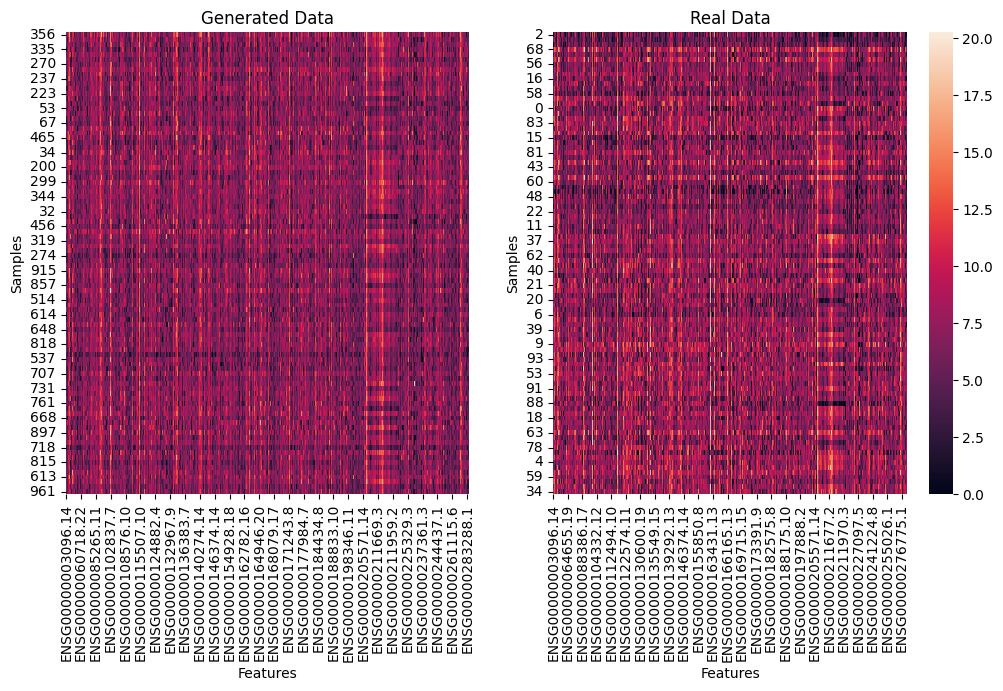

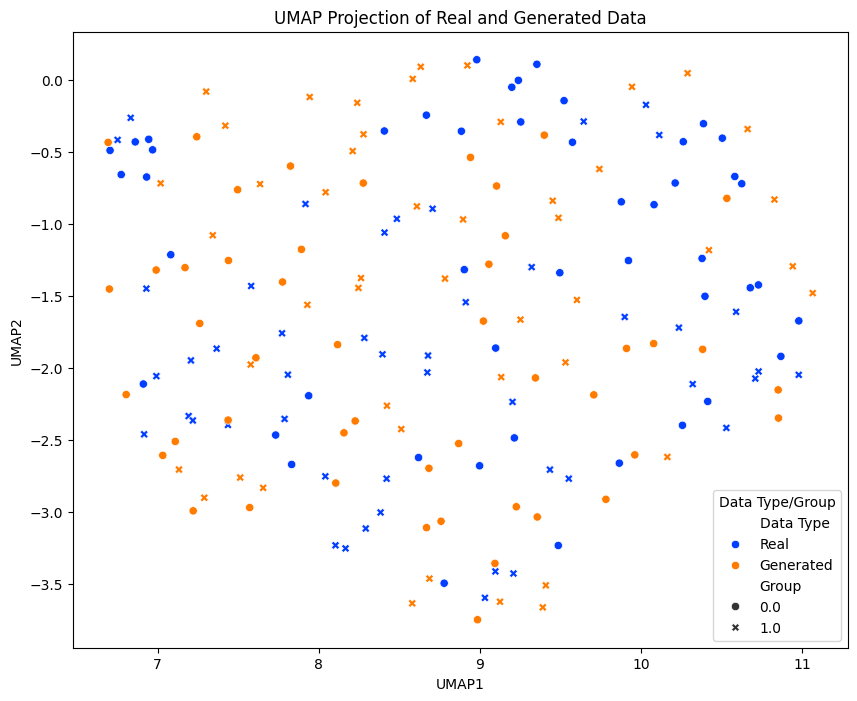

已删除临时文件: /Users/yanjiechen/Documents/Github/SyNG-BTS/syng_bts/Case/test_results/COAD_5-2/raw/batch_2/CVAE1-50/swap_cols_temp_8_f66i0t.csv
已删除临时文件: /Users/yanjiechen/Documents/Github/SyNG-BTS/syng_bts/Case/test_results/COAD_5-2/raw/batch_2/CVAE1-50/generated_skip1_1ow00wbu.csv


In [6]:
# === Input Real Data Description ===
# - 'samples': sample IDs (need to be removed)
# - 'groups': class labels (string or numeric; mapped to 0/1 if needed)
# - All other columns: raw feature values (e.g., expression counts)
# - The feature values in real need to be log-transformed: log2(real + 1)
real_file_name = r"/Users/yanjiechen/Documents/Github/SyNG-BTS/syng_bts/Case/test_results/COAD_5-2/raw/batch_2/CVAE1-50/COAD_5-2_raw_batch_2_test.csv" # Please replace it with your actual file path

# === Input Generated Data Description ===
# - generated.csv has the same columns as real except for samples
# - The features are already log-transformed
# - Group labels (0 or 1) are in the last colu
generated_file_name = r"/Users/yanjiechen/Documents/Github/SyNG-BTS/syng_bts/Case/test_results/COAD_5-2/raw/batch_2/CVAE1-50/COAD_5-2_raw_batch_2_train_epochES_batch01_CVAE1-100_generated.csv" # Please replace it with your actual file path

# 若 generated 文件是原始 counts（未做 log2(x+1)），需做 log 以与 real 的尺度一致；若已是 log，请将 generated_is_raw_counts 改为 False
generated_is_raw_counts = False



# Check if the second-to-last column is all zeros, and create a temp file if needed
import csv
import tempfile
import os

temp_file_path = None
try:
    # Read the file and check the second-to-last column
    with open(generated_file_name, 'r') as f:
        reader = csv.reader(f)
        rows = list(reader)
        
        if rows and len(rows[0]) > 1:
            # Check if second-to-last column (index -2) is all zeros
            second_to_last_col_idx = -2
            second_to_last_col_values = []
            for row in rows:
                if len(row) > abs(second_to_last_col_idx):
                    val = row[second_to_last_col_idx].strip() if isinstance(row[second_to_last_col_idx], str) else str(row[second_to_last_col_idx])
                    second_to_last_col_values.append(val)
            
            # Check if all values are effectively zero (0, 0.0, or scientific notation of 0)
            def is_zero_value(val_str):
                try:
                    float_val = float(val_str)
                    return abs(float_val) < 1e-10  # Consider values very close to 0 as zero
                except (ValueError, TypeError):
                    return val_str == '' or val_str == '0' or val_str == '0.0'
            
            is_all_zero = all(is_zero_value(val) for val in second_to_last_col_values) if second_to_last_col_values else False
            
            if is_all_zero:
                print(f"检测到倒数第二列全为0，创建临时文件并移除该列...")
                # Create a temporary file
                temp_fd, temp_file_path = tempfile.mkstemp(suffix='.csv', prefix='generated_temp_', dir=os.path.dirname(generated_file_name) or '.')
                os.close(temp_fd)  # Close the file descriptor, we'll use the path
                
                # Write the data without the second-to-last column
                with open(temp_file_path, 'w', newline='') as f_out:
                    writer = csv.writer(f_out)
                    for row in rows:
                        if len(row) > 1:
                            # Remove the second-to-last column
                            new_row = row[:second_to_last_col_idx] + row[second_to_last_col_idx+1:]
                            writer.writerow(new_row)
                        else:
                            writer.writerow(row)
                
                # Use the temp file for subsequent operations
                generated_file_name = temp_file_path
                print(f"已创建临时文件: {temp_file_path}")
            else:
                print(f"倒数第二列不全为0，使用原始文件")
except Exception as e:
    print(f"检查文件时出错: {e}")
    import traceback
    traceback.print_exc()

# Check if the last two columns are "samples, groups" and swap them if needed
temp_files_to_cleanup = []  # 用于跟踪所有需要清理的临时文件

def swap_last_two_columns_if_needed(file_path):
    """
    检查文件的最后两列是否为"samples, groups"，如果是则交换顺序为"groups, samples"
    
    Parameters:
    -----------
    file_path : str
        要检查的CSV文件路径
    
    Returns:
    --------
    str
        如果交换了列，返回临时文件路径；否则返回原始文件路径
    """
    global temp_files_to_cleanup
    temp_file_path = None
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            reader = csv.reader(f)
            rows = list(reader)
        
        if rows and len(rows[0]) >= 2:
            # 获取表头（第一行）
            header = rows[0]
            last_two_cols = header[-2:]
            
            # 检查最后两列是否为"samples"和"groups"
            if len(last_two_cols) == 2 and last_two_cols[0].strip() == 'samples' and last_two_cols[1].strip() == 'groups':
                print(f"检测到文件 {file_path} 的最后两列为'samples, groups'，正在交换顺序...")
                
                # 创建临时文件
                temp_fd, temp_file_path = tempfile.mkstemp(suffix='.csv', prefix='swap_cols_temp_', dir=os.path.dirname(file_path) or '.')
                os.close(temp_fd)
                
                # 写入交换列后的数据
                with open(temp_file_path, 'w', newline='', encoding='utf-8') as f_out:
                    writer = csv.writer(f_out)
                    for row in rows:
                        if len(row) >= 2:
                            # 交换最后两列：将倒数第二列和最后一列交换
                            new_row = row[:-2] + [row[-1], row[-2]]
                            writer.writerow(new_row)
                        else:
                            writer.writerow(row)
                
                # 记录临时文件以便后续清理
                temp_files_to_cleanup.append(temp_file_path)
                print(f"已创建交换列后的临时文件: {temp_file_path}")
                return temp_file_path
            else:
                print(f"文件 {file_path} 的最后两列不是'samples, groups'，无需交换")
                return file_path
        else:
            return file_path
    except Exception as e:
        print(f"检查文件 {file_path} 的列顺序时出错: {e}")
        import traceback
        traceback.print_exc()
        return file_path

# 对两个文件都进行检查和交换
real_file_name = swap_last_two_columns_if_needed(real_file_name)
generated_file_name = swap_last_two_columns_if_needed(generated_file_name)

# 去掉 generated 的第一行（表头），以匹配 get_data_metrics 的旧版格式（header=None、无表头）
try:
    _df_gen = pd.read_csv(generated_file_name, header=0)
    _fd, _gen_skip1 = tempfile.mkstemp(suffix='.csv', prefix='generated_skip1_', dir=os.path.dirname(generated_file_name) or '.')
    os.close(_fd)
    _df_gen.to_csv(_gen_skip1, index=False, header=False)
    generated_file_name = _gen_skip1
    temp_files_to_cleanup.append(_gen_skip1)
except Exception as e:
    print(f"去掉 generated 第一行时出错: {e}")

# Load and preprocess real and generated datasets:
# - real_data: log2-transformed numeric features from the real dataset
# - groups_real: binary-encoded labels (0/1) for the real data
# - generated_data: numeric features from the generated dataset
# - groups_generated: group labels from the generated data
# - unique_types: array of unique class labels (e.g., [0, 1])
real, groups_real, generated, groups_generated, unique_types = get_data_metrics(real_file_name, generated_file_name)


if generated_is_raw_counts:
    generated = pd.DataFrame(np.log2(generated.astype(float).values + 1), index=generated.index, columns=generated.columns)

# Visualize and evaluate real vs. generated data:
# - Stratified sampling is performed within each group based on the real data
# - 'ratio' determines the fraction of real samples to visualize per class
# - Heatmaps show the expression patterns of both datasets
# - UMAP plots show group-wise structure in 2D space
# - If generated data is None, only real data is visualized
visualize(real, groups_real, unique_types, generated, groups_generated, ratio=1, seed=88)

# Clean up temporary files if they were created
# 清理检查全0列时创建的临时文件
if temp_file_path is not None and os.path.exists(temp_file_path):
    try:
        os.remove(temp_file_path)
        print(f"已删除临时文件: {temp_file_path}")
    except Exception as e:
        print(f"删除临时文件时出错: {e}")

# 清理交换列时创建的所有临时文件
for temp_file in temp_files_to_cleanup:
    if temp_file is not None and os.path.exists(temp_file):
        try:
            os.remove(temp_file)
            print(f"已删除临时文件: {temp_file}")
        except Exception as e:
            print(f"删除临时文件 {temp_file} 时出错: {e}")

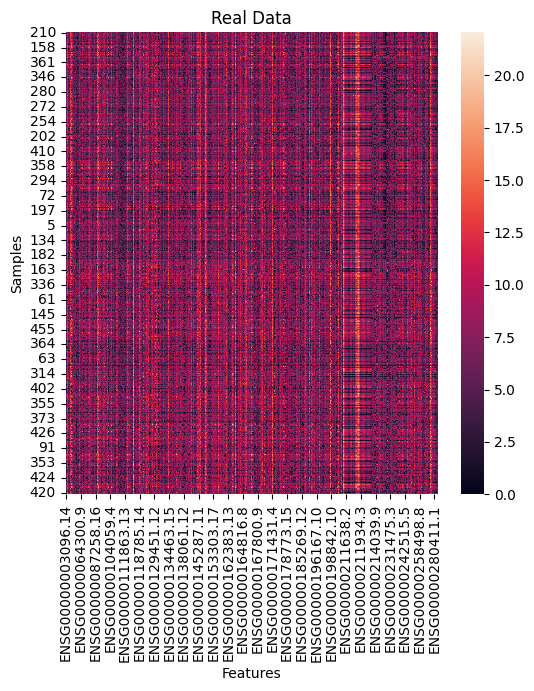

In [8]:
# If we only have the real samples...
visualize(real, groups_real, unique_types, ratio=1, seed=88)

# PRADSubtype classification accurary multiple classifier

In [6]:
# Create candidate sample sizes ranging from 'step' to the full size of real data
step = len(real) // 30
n_candidate = np.arange(step, len(real) + 1, step)
n_candidate = n_candidate[(n_candidate >= 12) & (n_candidate <= len(real))]

# Define target sizes that go beyond the candidate range (extrapolation)
n_target = np.array([n_candidate[-1] + x * step for x in range(1, 4)])
print(f'n_candidate: {n_candidate}\nn_target: {n_target}')

n_candidate: [ 12  18  24  30  36  42  48  54  60  66  72  78  84  90  96 102 108 114
 120 126 132 138 144 150 156 162 168 174 180 186 192 198]
n_target: [204 210 216]


In [7]:
# Evaluate the classifier for real data
metric_real = eval_classifier(whole_generated=real,
                              whole_groups=groups_real,
                              n_candidate=n_candidate,
                              n_draw=30, log=True)

# Save the results to csv file if necessary
metric_real.to_csv(f'LIHCSubtypeFamInd_DESeq_metric_real.csv', index=False)


Running sample size index 1/32 (n = 12)



/opt/anaconda3/envs/synthesize_env/lib/python3.11/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
/opt/anaconda3/envs/synthesize_env/lib/python3.11/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.


[n=12, draw=0, method=LOGIS] F1: 0.8667, Acc: 0.8667, AUC: 0.9000
[n=12, draw=0, method=SVM] F1: 0.8667, Acc: 0.8667, AUC: 0.2000
[n=12, draw=0, method=KNN] F1: 0.8667, Acc: 0.8667, AUC: 0.8500
[n=12, draw=0, method=RF] F1: 0.8667, Acc: 0.8667, AUC: 1.0000
[n=12, draw=0, method=XGB] F1: 0.7000, Acc: 0.7333, AUC: 0.8000


/opt/anaconda3/envs/synthesize_env/lib/python3.11/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
/opt/anaconda3/envs/synthesize_env/lib/python3.11/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.


[n=12, draw=1, method=LOGIS] F1: 0.8500, Acc: 0.8667, AUC: 0.9000
[n=12, draw=1, method=SVM] F1: 0.7333, Acc: 0.7333, AUC: 0.7000
[n=12, draw=1, method=KNN] F1: 0.8000, Acc: 0.8333, AUC: 0.8000
[n=12, draw=1, method=RF] F1: 0.7333, Acc: 0.7667, AUC: 0.8000
[n=12, draw=1, method=XGB] F1: 0.7000, Acc: 0.7333, AUC: 0.8000


...

[n=12, draw=15, method=LOGIS] F1: 0.3000, Acc: 0.3333, AUC: 0.3000
[n=12, draw=15, method=SVM] F1: 0.3000, Acc: 0.3333, AUC: 0.6000
[n=12, draw=15, method=KNN] F1: 0.3833, Acc: 0.4000, AUC: 0.3500
[n=12, draw=15, method=RF] F1: 0.2500, Acc: 0.3000, AUC: 0.4000
[n=12, draw=15, method=XGB] F1: 0.3000, Acc: 0.3333, AUC: 0.4000


/opt/anaconda3/envs/synthesize_env/lib/python3.11/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
/opt/anaconda3/envs/synthesize_env/lib/python3.11/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.


[n=12, draw=16, method=LOGIS] F1: 0.6667, Acc: 0.6667, AUC: 0.8000
[n=12, draw=16, method=SVM] F1: 0.5833, Acc: 0.6000, AUC: 0.6000
[n=12, draw=16, method=KNN] F1: 0.7333, Acc: 0.7333, AUC: 0.7500
[n=12, draw=16, method=RF] F1: 0.6667, Acc: 0.6667, AUC: 0.7000
[n=12, draw=16, method=XGB] F1: 0.7000, Acc: 0.7333, AUC: 0.8000


/opt/anaconda3/envs/synthesize_env/lib/python3.11/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
/opt/anaconda3/envs/synthesize_env/lib/python3.11/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.


: 

In [21]:
# Evaluate the classifier for generated data
metric_generated = eval_classifier(whole_generated=generated,
                                   whole_groups=groups_generated,
                                   n_candidate=n_candidate,
                                   n_draw=30, log=True)

# Save the results to csv file if necessary
metric_generated.to_csv(f'LIHCSubtypeFamInd_DESeq_metric_generated.csv', index=False)


Running sample size index 1/32 (n = 12)



/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.


[n=12, draw=0, method=LOGIS] F1: 0.7833, Acc: 0.8000, AUC: 0.8000
[n=12, draw=0, method=SVM] F1: 0.5833, Acc: 0.6000, AUC: 0.5000
[n=12, draw=0, method=KNN] F1: 0.4500, Acc: 0.5000, AUC: 0.5500
[n=12, draw=0, method=RF] F1: 0.4500, Acc: 0.4667, AUC: 0.5000
[n=12, draw=0, method=XGB] F1: 0.5000, Acc: 0.5333, AUC: 0.6000


/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.


[n=12, draw=1, method=LOGIS] F1: 0.5000, Acc: 0.5333, AUC: 0.6000
[n=12, draw=1, method=SVM] F1: 0.6667, Acc: 0.6667, AUC: 0.4000
[n=12, draw=1, method=KNN] F1: 0.3167, Acc: 0.4000, AUC: 0.4500
[n=12, draw=1, method=RF] F1: 0.5833, Acc: 0.6000, AUC: 0.6000
[n=12, draw=1, method=XGB] F1: 0.5000, Acc: 0.5333, AUC: 0.6000


...

[n=12, draw=27, method=LOGIS] F1: 0.5833, Acc: 0.6000, AUC: 0.7000
[n=12, draw=27, method=SVM] F1: 0.5333, Acc: 0.5667, AUC: 0.3000
[n=12, draw=27, method=KNN] F1: 0.6000, Acc: 0.6667, AUC: 0.6000
[n=12, draw=27, method=RF] F1: 0.3833, Acc: 0.4000, AUC: 0.5000
[n=12, draw=27, method=XGB] F1: 0.5000, Acc: 0.5333, AUC: 0.6000


/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.


[n=12, draw=28, method=LOGIS] F1: 0.1333, Acc: 0.1333, AUC: 0.2000
[n=12, draw=28, method=SVM] F1: 0.0500, Acc: 0.0667, AUC: 0.8000
[n=12, draw=28, method=KNN] F1: 0.4500, Acc: 0.5000, AUC: 0.4500
[n=12, draw=28, method=RF] F1: 0.1333, Acc: 0.1333, AUC: 0.1500
[n=12, draw=28, method=XGB] F1: 0.3667, Acc: 0.4333, AUC: 0.6000


/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.


[n=12, draw=29, method=LOGIS] F1: 0.5000, Acc: 0.5333, AUC: 0.5000
[n=12, draw=29, method=SVM] F1: 0.5833, Acc: 0.6000, AUC: 0.4000
[n=12, draw=29, method=KNN] F1: 0.5333, Acc: 0.5667, AUC: 0.5500
[n=12, draw=29, method=RF] F1: 0.5000, Acc: 0.5333, AUC: 0.5000
[n=12, draw=29, method=XGB] F1: 0.3000, Acc: 0.3333, AUC: 0.4000

Running sample size index 2/32 (n = 14)

[n=14, draw=0, method=LOGIS] F1: 0.1833, Acc: 0.2000, AUC: 0.2000
[n=14, draw=0, method=SVM] F1: 0.4333, Acc: 0.5000, AUC: 0.4000
[n=14, draw=0, method=KNN] F1: 0.4667, Acc: 0.5000, AUC: 0.5500
[n=14, draw=0, method=RF] F1: 0.5167, Acc: 0.5333, AUC: 0.6000
[n=14, draw=0, method=XGB] F1: 0.5167, Acc: 0.5333, AUC: 0.6000
[n=14, draw=1, method=LOGIS] F1: 0.3833, Acc: 0.4000, AUC: 0.5000
[n=14, draw=1, method=SVM] F1: 0.1500, Acc: 0.2000, AUC: 0.7000
[n=14, draw=1, method=KNN] F1: 0.2333, Acc: 0.2667, AUC: 0.2500
[n=14, draw=1, method=RF] F1: 0.1000, Acc: 0.1333, AUC: 0.0000
[n=14, draw=1, method=XGB] F1: 0.1500, Acc: 0.2000, AU

In [25]:
# If we have already saved the results
# metric_real = pd.read_csv(f'PRADSubtype_icd_o_3_histology_metric_real.csv',header = 0)
# metric_generated = pd.read_csv(f'PRADSubtype_icd_o_3_histology_metric_generated.csv',header = 0)

LOGIS
SVM
KNN
RF
XGB


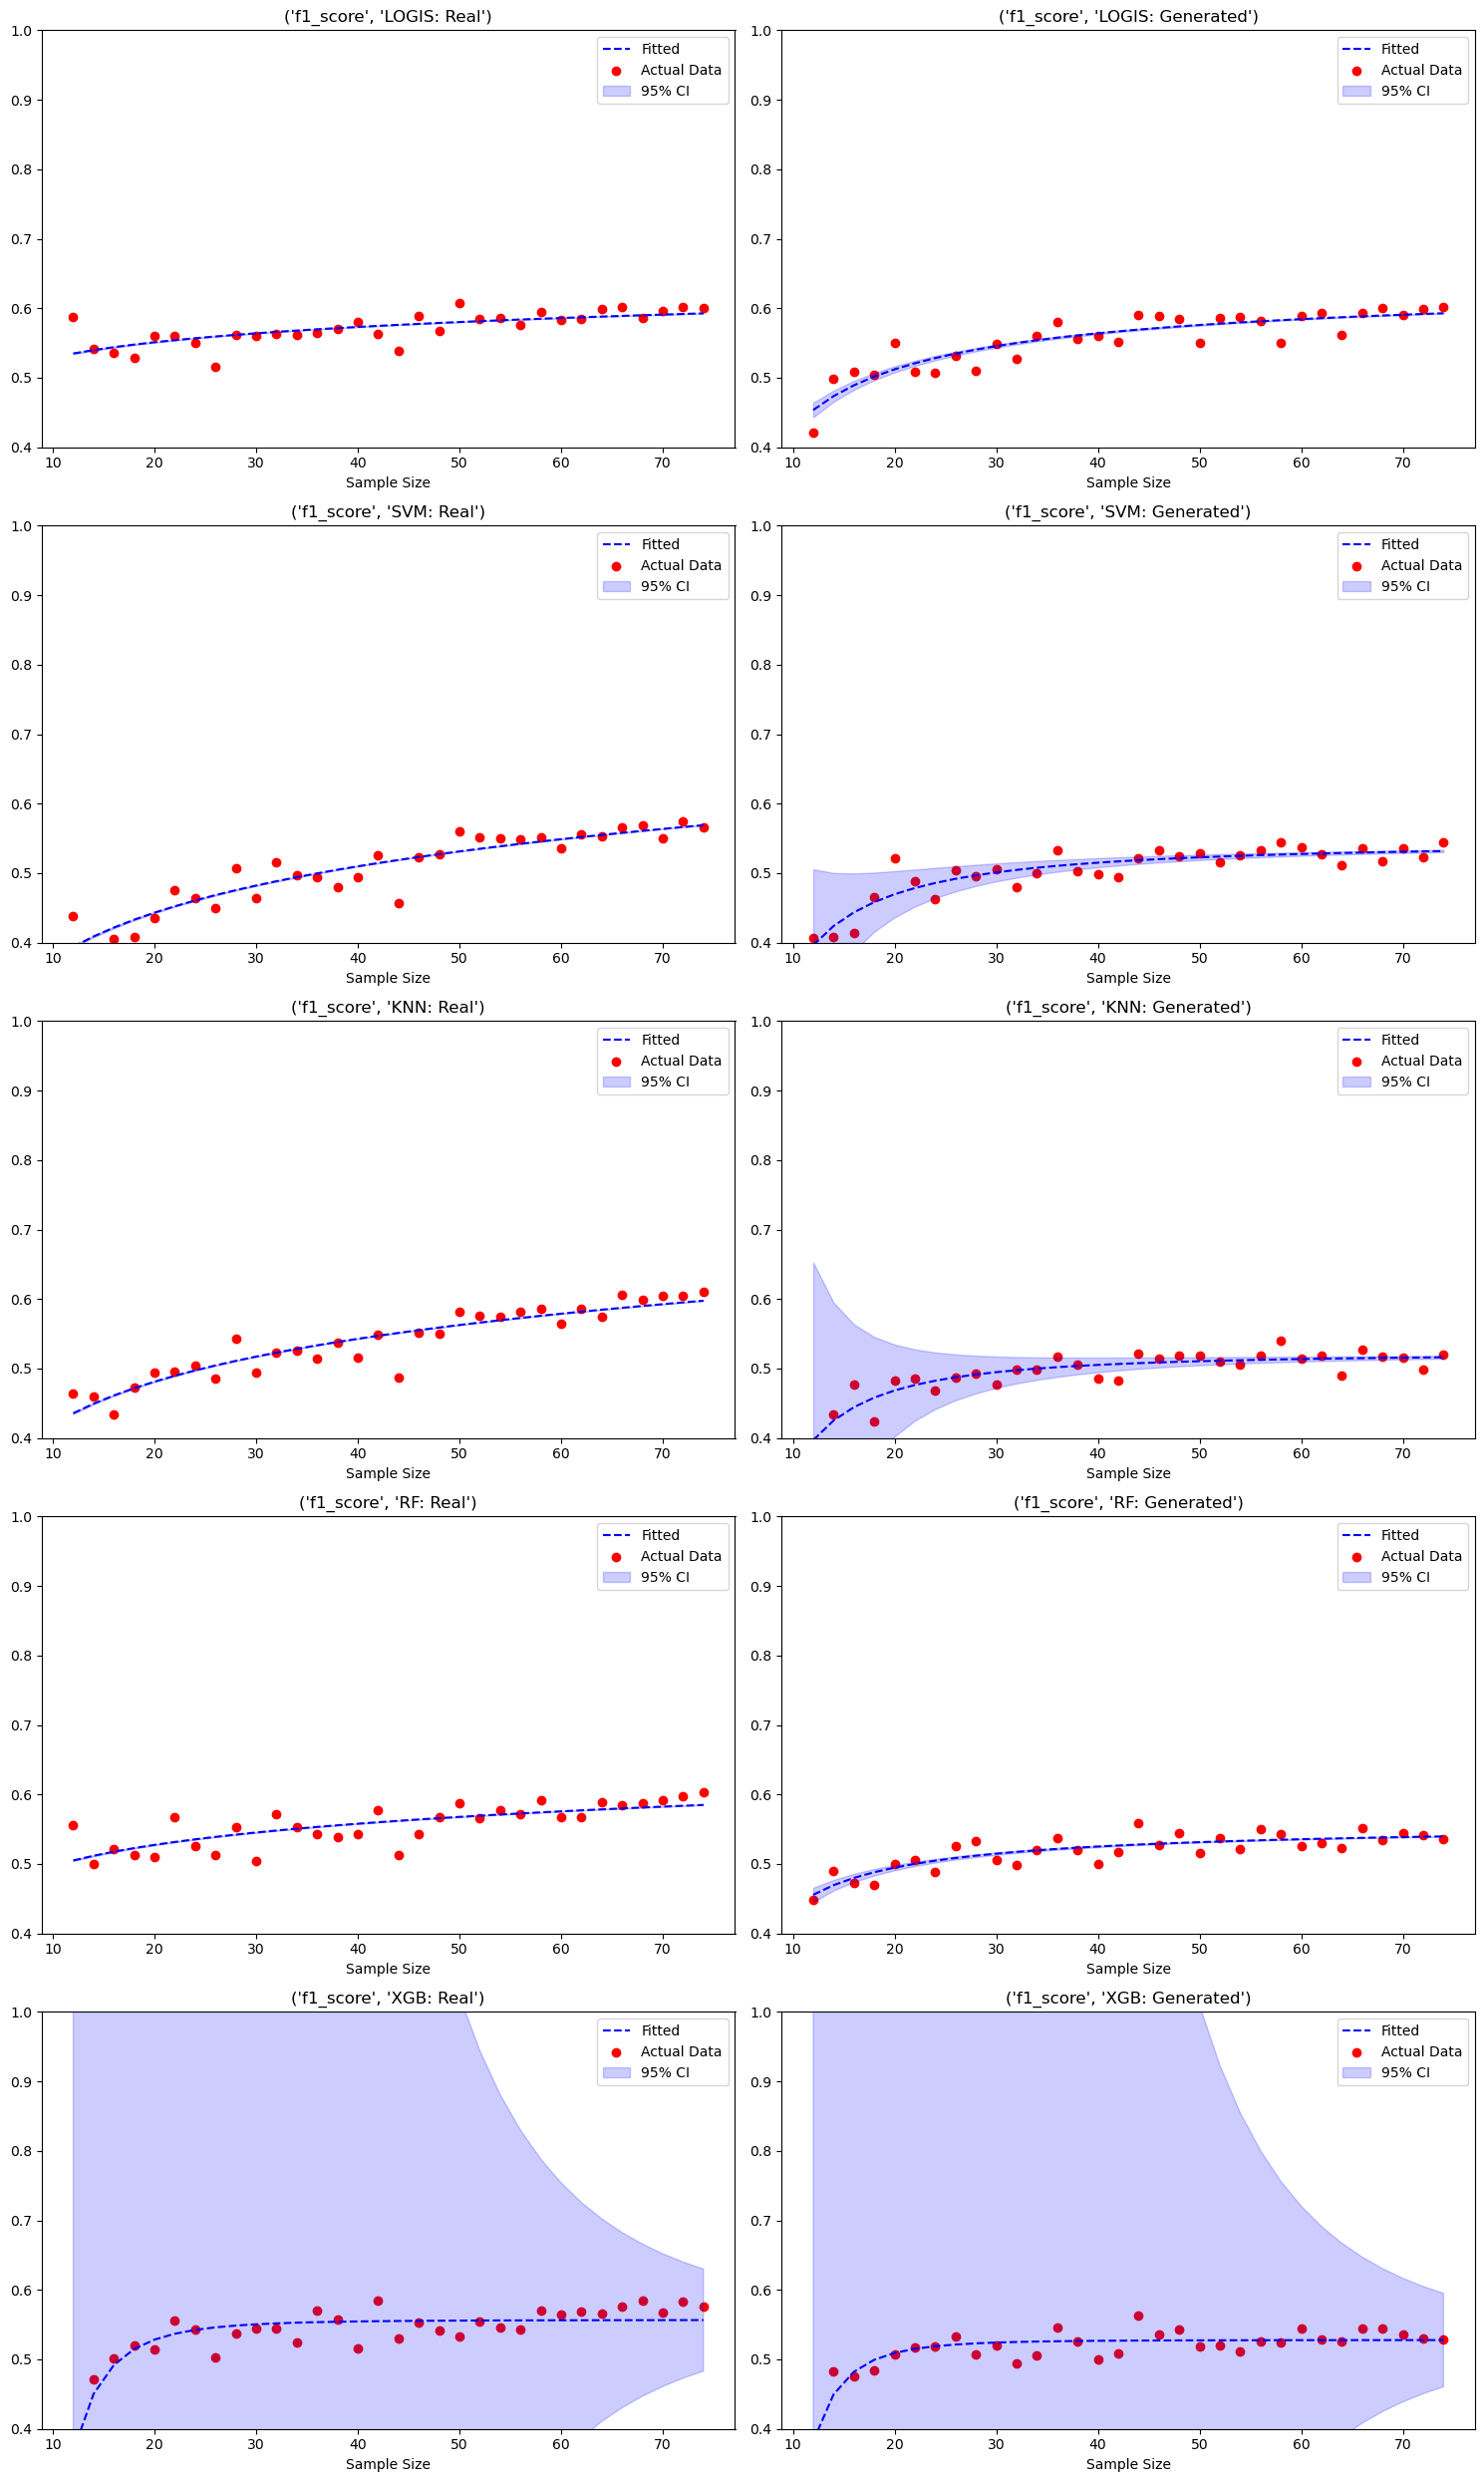

In [24]:
# Visualize the classifier performance
import matplotlib.pyplot as plt
p_acc = vis_classifier(metric_generated=metric_generated,
                       metric_real=metric_real,
                       metric_name='f1_score',
                       n_target=n_target, save = False)

In [26]:
real_file_name = r"./Case/LIHCSubtypeFamInd_test74.csv"
generated_file_name = r"./Case/LIHCSubtypeFamInd_train294_epochES_batch01_CVAE1-10_generated.csv"
real, groups_real, generated, groups_generated, unique_types = get_data_metrics(real_file_name, generated_file_name)

In [27]:
step = len(real) // 30
n_candidate = np.arange(step, len(real) + 1, step)
n_candidate = n_candidate[(n_candidate >= 12) & (n_candidate <= len(real))]

# Define target sizes that go beyond the candidate range (extrapolation)
n_target = np.array([n_candidate[-1] + x * step for x in range(1, 4)])
print(f'n_candidate: {n_candidate}\nn_target: {n_target}')

n_candidate: [12 14 16 18 20 22 24 26 28 30 32 34 36 38 40 42 44 46 48 50 52 54 56 58
 60 62 64 66 68 70 72 74]
n_target: [76 78 80]


In [28]:
metric_real = eval_classifier(whole_generated=real,
                              whole_groups=groups_real,
                              n_candidate=n_candidate,
                              n_draw=30, log=True)

# Save the results to csv file if necessary
metric_real.to_csv(f'LIHCSubtypeFamInd_metric_real.csv', index=False)


Running sample size index 1/32 (n = 12)



/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.


[n=12, draw=0, method=LOGIS] F1: 0.7333, Acc: 0.7333, AUC: 0.7000
[n=12, draw=0, method=SVM] F1: 0.5000, Acc: 0.5333, AUC: 0.1000
[n=12, draw=0, method=KNN] F1: 0.5000, Acc: 0.5333, AUC: 0.5500
[n=12, draw=0, method=RF] F1: 0.6000, Acc: 0.6333, AUC: 0.5000
[n=12, draw=0, method=XGB] F1: 0.3000, Acc: 0.3333, AUC: 0.4000


/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.


[n=12, draw=1, method=LOGIS] F1: 0.1333, Acc: 0.1333, AUC: 0.1000
[n=12, draw=1, method=SVM] F1: 0.1833, Acc: 0.2667, AUC: 0.4000
[n=12, draw=1, method=KNN] F1: 0.1167, Acc: 0.1667, AUC: 0.1500
[n=12, draw=1, method=RF] F1: 0.3333, Acc: 0.3333, AUC: 0.4000
[n=12, draw=1, method=XGB] F1: 0.5000, Acc: 0.5333, AUC: 0.6000


...

[n=14, draw=27, method=LOGIS] F1: 0.6500, Acc: 0.7000, AUC: 0.9000
[n=14, draw=27, method=SVM] F1: 0.3567, Acc: 0.5667, AUC: 0.3000
[n=14, draw=27, method=KNN] F1: 0.2300, Acc: 0.3333, AUC: 0.4000
[n=14, draw=27, method=RF] F1: 0.5833, Acc: 0.6000, AUC: 0.7000
[n=14, draw=27, method=XGB] F1: 0.6500, Acc: 0.6667, AUC: 0.7500


/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.


[n=14, draw=28, method=LOGIS] F1: 0.4000, Acc: 0.4000, AUC: 0.3000
[n=14, draw=28, method=SVM] F1: 0.3567, Acc: 0.5667, AUC: 0.7000
[n=14, draw=28, method=KNN] F1: 0.3800, Acc: 0.5000, AUC: 0.5000
[n=14, draw=28, method=RF] F1: 0.2833, Acc: 0.3333, AUC: 0.2500
[n=14, draw=28, method=XGB] F1: 0.6133, Acc: 0.7000, AUC: 0.5500


/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.


[n=14, draw=29, method=LOGIS] F1: 0.4333, Acc: 0.4667, AUC: 0.4000
[n=14, draw=29, method=SVM] F1: 0.3267, Acc: 0.5000, AUC: 0.8000
[n=14, draw=29, method=KNN] F1: 0.2000, Acc: 0.2000, AUC: 0.2000
[n=14, draw=29, method=RF] F1: 0.1967, Acc: 0.3000, AUC: 0.4000
[n=14, draw=29, method=XGB] F1: 0.1500, Acc: 0.2000, AUC: 0.2000

Running sample size index 3/32 (n = 16)

[n=16, draw=0, method=LOGIS] F1: 0.3800, Acc: 0.4167, AUC: 0.3500
[n=16, draw=0, method=SVM] F1: 0.3267, Acc: 0.5000, AUC: 0.2000
[n=16, draw=0, method=KNN] F1: 0.3600, Acc: 0.4167, AUC: 0.4000
[n=16, draw=0, method=RF] F1: 0.3800, Acc: 0.4167, AUC: 0.5000
[n=16, draw=0, method=XGB] F1: 0.3467, Acc: 0.4167, AUC: 0.2000
[n=16, draw=1, method=LOGIS] F1: 0.1900, Acc: 0.2500, AUC: 0.1500
[n=16, draw=1, method=SVM] F1: 0.3267, Acc: 0.5000, AUC: 0.9500
[n=16, draw=1, method=KNN] F1: 0.2000, Acc: 0.2333, AUC: 0.1500
[n=16, draw=1, method=RF] F1: 0.2233, Acc: 0.2500, AUC: 0.2250
[n=16, draw=1, method=XGB] F1: 0.1500, Acc: 0.2000, AU

In [29]:
metric_generated = eval_classifier(whole_generated=generated,
                                   whole_groups=groups_generated,
                                   n_candidate=n_candidate,
                                   n_draw=30, log=True)

# Save the results to csv file if necessary
metric_generated.to_csv(f'LIHCSubtypeFamInd_metric_generated.csv', index=False)


Running sample size index 1/32 (n = 12)



/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.


[n=12, draw=0, method=LOGIS] F1: 0.5333, Acc: 0.5667, AUC: 0.8000
[n=12, draw=0, method=SVM] F1: 0.6667, Acc: 0.6667, AUC: 0.3000
[n=12, draw=0, method=KNN] F1: 0.4667, Acc: 0.4667, AUC: 0.5000
[n=12, draw=0, method=RF] F1: 0.4667, Acc: 0.4667, AUC: 0.6000
[n=12, draw=0, method=XGB] F1: 0.3000, Acc: 0.3333, AUC: 0.4000


/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.


[n=12, draw=1, method=LOGIS] F1: 0.3333, Acc: 0.3333, AUC: 0.4000
[n=12, draw=1, method=SVM] F1: 0.1833, Acc: 0.2667, AUC: 0.4000
[n=12, draw=1, method=KNN] F1: 0.1333, Acc: 0.2000, AUC: 0.1000
[n=12, draw=1, method=RF] F1: 0.1333, Acc: 0.2000, AUC: 0.2000
[n=12, draw=1, method=XGB] F1: 0.3000, Acc: 0.3333, AUC: 0.4000


...

[n=12, draw=27, method=LOGIS] F1: 0.5833, Acc: 0.6000, AUC: 0.5000
[n=12, draw=27, method=SVM] F1: 0.5833, Acc: 0.6000, AUC: 0.3000
[n=12, draw=27, method=KNN] F1: 0.5000, Acc: 0.5333, AUC: 0.6500
[n=12, draw=27, method=RF] F1: 0.6667, Acc: 0.6667, AUC: 0.7000
[n=12, draw=27, method=XGB] F1: 0.5000, Acc: 0.5333, AUC: 0.6000


/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.


[n=12, draw=28, method=LOGIS] F1: 0.2667, Acc: 0.2667, AUC: 0.2000
[n=12, draw=28, method=SVM] F1: 0.3833, Acc: 0.4000, AUC: 0.5000
[n=12, draw=28, method=KNN] F1: 0.5333, Acc: 0.5667, AUC: 0.4500
[n=12, draw=28, method=RF] F1: 0.2000, Acc: 0.2333, AUC: 0.1000
[n=12, draw=28, method=XGB] F1: 0.2333, Acc: 0.3333, AUC: 0.6000


/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.


[n=12, draw=29, method=LOGIS] F1: 0.5833, Acc: 0.6000, AUC: 0.6000
[n=12, draw=29, method=SVM] F1: 0.4500, Acc: 0.5000, AUC: 0.7000
[n=12, draw=29, method=KNN] F1: 0.7333, Acc: 0.7667, AUC: 0.7500
[n=12, draw=29, method=RF] F1: 0.6500, Acc: 0.7000, AUC: 0.5000
[n=12, draw=29, method=XGB] F1: 0.3000, Acc: 0.3333, AUC: 0.4000

Running sample size index 2/32 (n = 14)

[n=14, draw=0, method=LOGIS] F1: 0.3000, Acc: 0.3333, AUC: 0.4000
[n=14, draw=0, method=SVM] F1: 0.2667, Acc: 0.3667, AUC: 0.5000
[n=14, draw=0, method=KNN] F1: 0.4500, Acc: 0.5000, AUC: 0.4000
[n=14, draw=0, method=RF] F1: 0.3833, Acc: 0.4000, AUC: 0.3000
[n=14, draw=0, method=XGB] F1: 0.3833, Acc: 0.4000, AUC: 0.4000
[n=14, draw=1, method=LOGIS] F1: 0.6500, Acc: 0.6667, AUC: 0.7000
[n=14, draw=1, method=SVM] F1: 0.5167, Acc: 0.5333, AUC: 0.3000
[n=14, draw=1, method=KNN] F1: 0.4500, Acc: 0.4667, AUC: 0.4500
[n=14, draw=1, method=RF] F1: 0.6500, Acc: 0.6667, AUC: 0.7000
[n=14, draw=1, method=XGB] F1: 0.5833, Acc: 0.6000, AU

LOGIS
SVM
KNN
RF
XGB


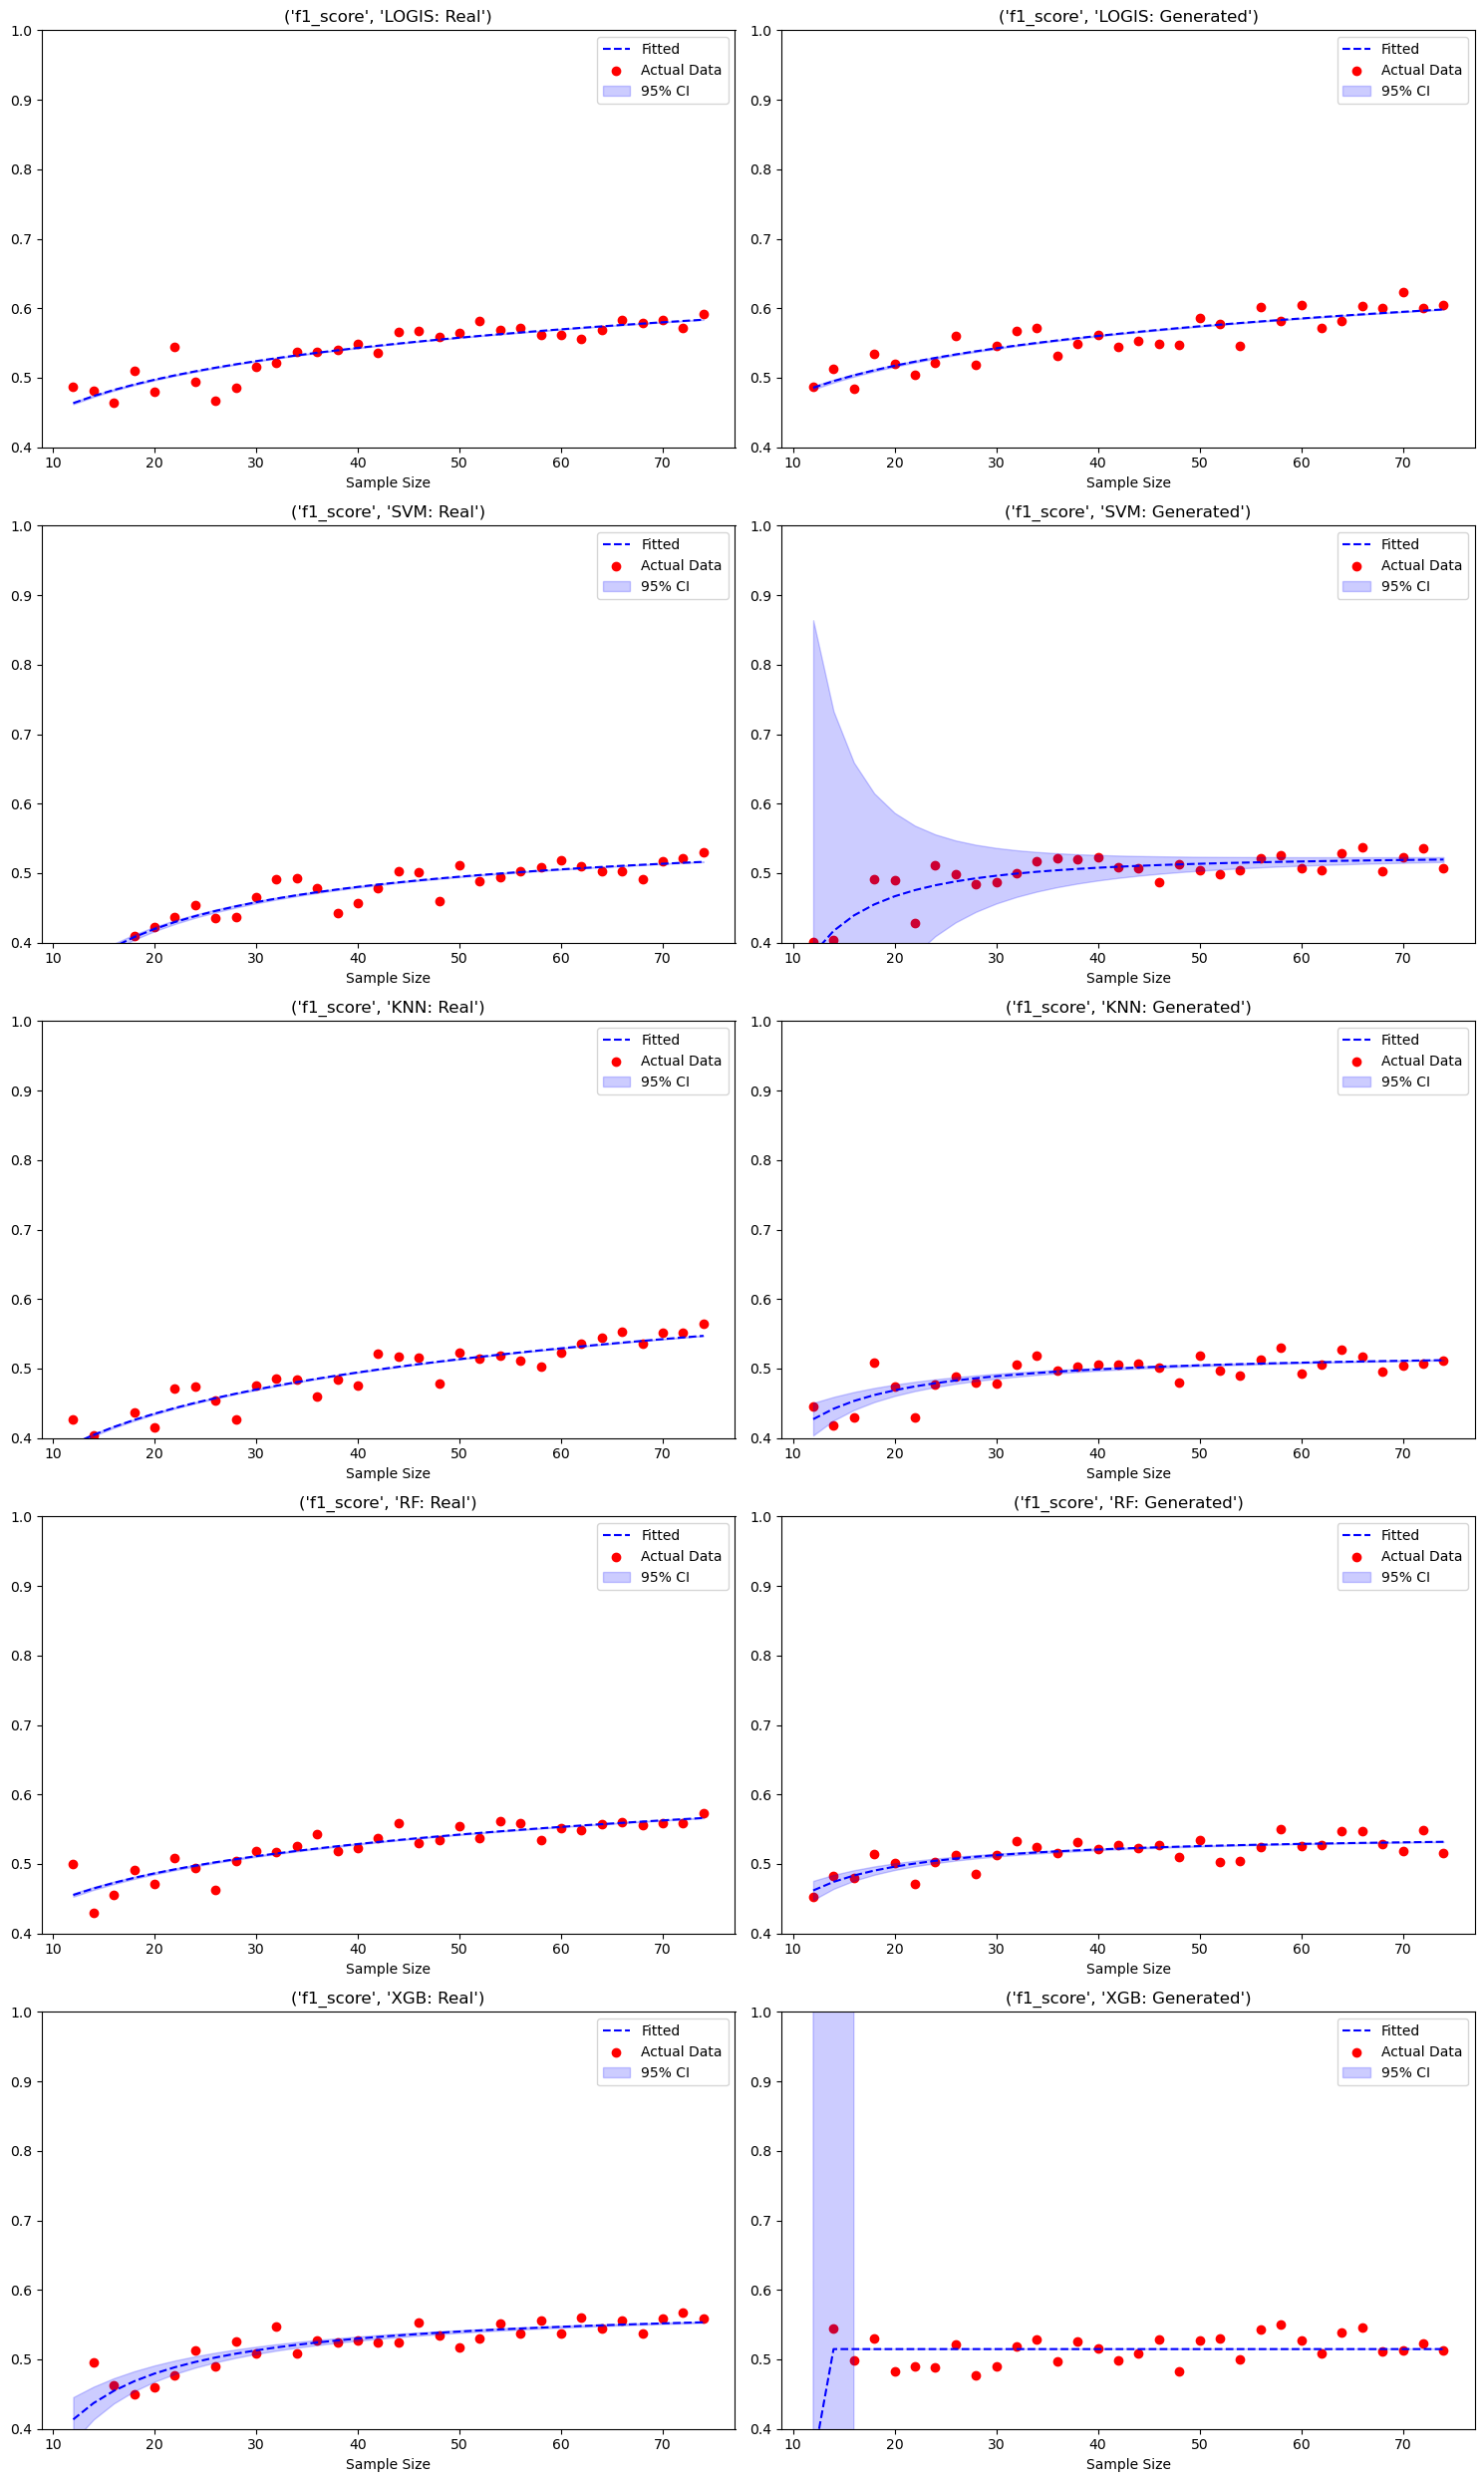

In [30]:
import matplotlib.pyplot as plt
p_acc = vis_classifier(metric_generated=metric_generated,
                       metric_real=metric_real,
                       metric_name='f1_score',
                       n_target=n_target, save = False)